# Using `pes_diagram` in a Jupyter notebook

This notebook shows how to draw potential-energy-surface (PES) diagrams with the
`PESDiagram` class.

**Setup:** put `pes_diagram.py` in the same folder as this notebook, then run the
cells top to bottom. Each `plot()` call renders inline.

In [1]:
%matplotlib inline
from pes_diagram import PESDiagram, build_ladder

## 1. A single pathway

Describe the path as an ordered list of states:

- `("label", energy)` &rarr; a minimum (reactant / intermediate / product)
- `("label", energy, "ts")` &rarr; a transition state (barrier)

`reference=` names the state that should sit at 0 eV; everything is shifted to it
and a dotted reference line is drawn.

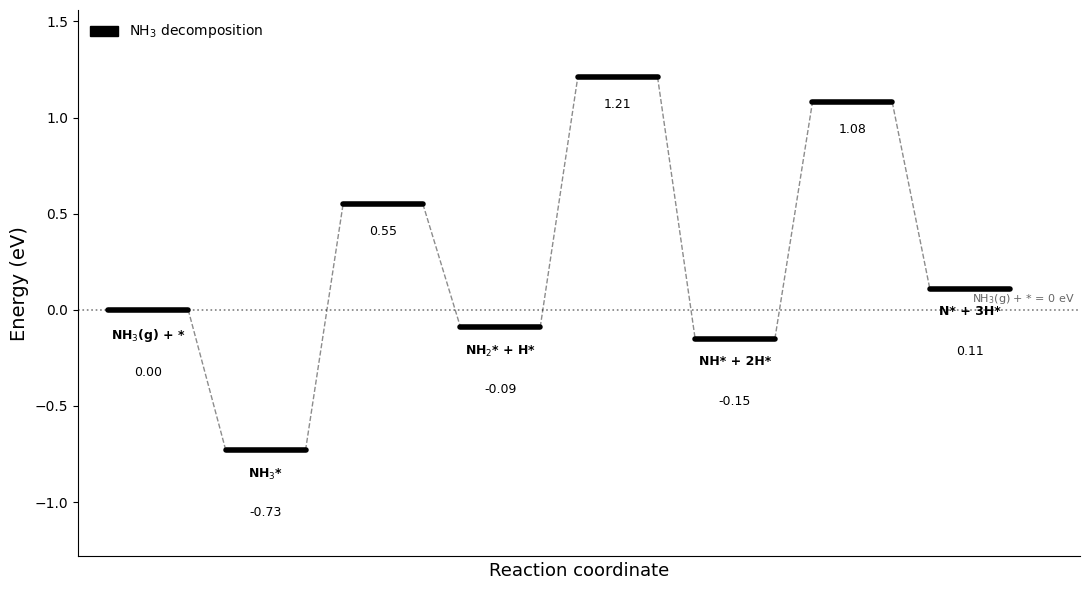

In [ ]:
d = PESDiagram(reference="NH$_3$(g) + *")

d.add_path("NH$_3$ decomposition", [
    ("NH$_3$(g) + *",  0.00),
    ("NH$_3$*",       -0.73),
    ("TS",             0.55, "ts"),
    ("NH$_2$* + H*",  -0.09),
    ("TS",             1.21, "ts"),
    ("NH* + 2H*",     -0.15),
    ("TS",             2.08, "ts"),
    ("N* + 3H*",       0.11),
])

fig, ax = d.plot()          # assigning fig, ax keeps the cell output clean

## 2. Overlay two branches on a common gas-phase reference

Build each branch from `(Ea, dE, product)` steps with `build_ladder`, which chains
the barriers into a cumulative profile (reactant = 0). Passing an adsorbate label +
`E_ads` makes the branch start at the gas species and drop into the adsorption well.

Give each path a **`gas_energy`** = the energy of its gas-phase reference on a common
scale. The plotter sets the **lower** gas species to 0 and shifts the higher branch up
by the gap. **You set the two `gas_energy` values; the offset is computed for you.**

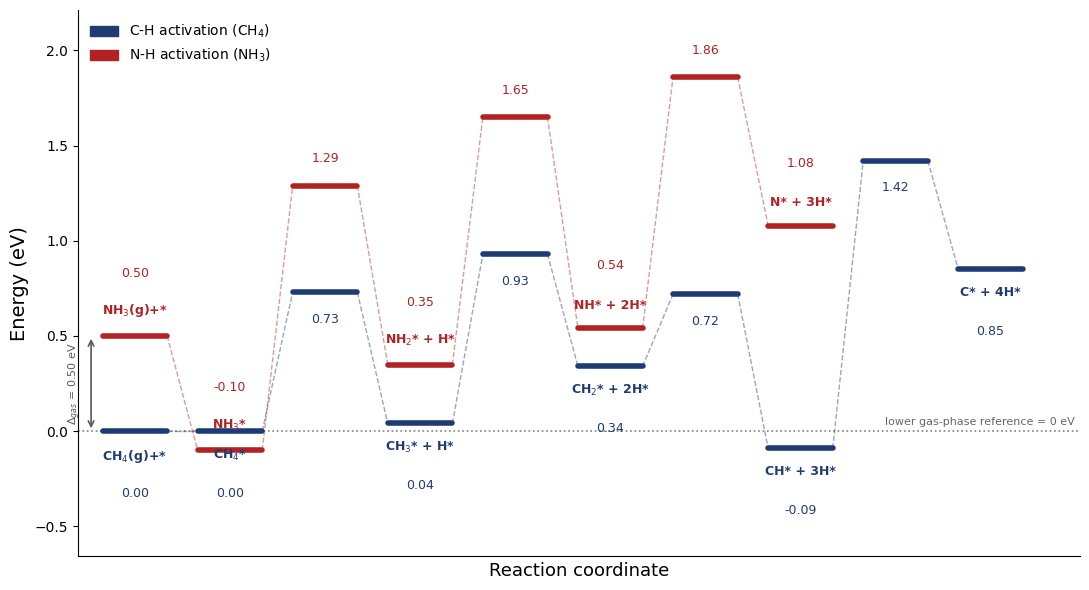

In [3]:
# ---- your inputs (replace with your own DFT numbers) ----
E_gas_CH4 = 0.00     # CH4(g) reference
E_gas_NH3 = 0.50     # NH3(g) reference  ->  gap = 0.50 eV, so NH3 branch shifts +0.50
Eads_CH4, Eads_NH3 = 0.00, 0.60          # adsorption energies (0 = no well)

# dehydrogenation steps: (Ea, dE, product)   [DFT Table 1, JPCC 2011, 115, 5667]
ch4 = build_ladder("CH$_4$(g)+*", [
    (0.73,  0.04, "CH$_3$* + H*"),
    (0.89,  0.30, "CH$_2$* + 2H*"),
    (0.38, -0.43, "CH* + 3H*"),
    (1.51,  0.94, "C* + 4H*"),
], adsorbate_label="CH$_4$*", E_ads=Eads_CH4)

nh3 = build_ladder("NH$_3$(g)+*", [
    (1.39,  0.45, "NH$_2$* + H*"),
    (1.30,  0.19, "NH* + 2H*"),
    (1.32,  0.54, "N* + 3H*"),
], adsorbate_label="NH$_3$*", E_ads=Eads_NH3)

d = PESDiagram()
d.add_path("C-H activation (CH$_4$)", ch4, color="#1f3b73",
           label_side="below", gas_energy=E_gas_CH4)
d.add_path("N-H activation (NH$_3$)", nh3, color="#b22222",
           label_side="above", gas_energy=E_gas_NH3)

fig, ax = d.plot(zero_line=True, show_gas_gap=True)

### Change the offset

Only the *difference* between the two `gas_energy` values matters. Change one number
and re-run &mdash; the lower branch stays at 0 and the other re-shifts automatically.
Below the gap is widened to 1.0 eV.

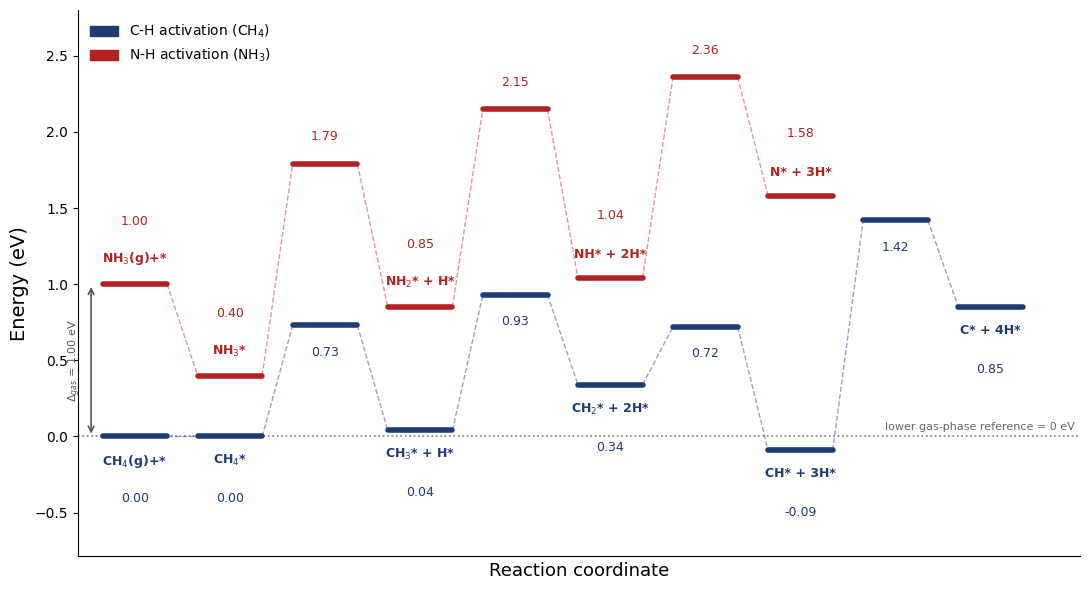

In [4]:
d = PESDiagram()
d.add_path("C-H activation (CH$_4$)", ch4, color="#1f3b73",
           label_side="below", gas_energy=0.0)
d.add_path("N-H activation (NH$_3$)", nh3, color="#b22222",
           label_side="above", gas_energy=1.0)   # <-- gap now 1.0 eV
fig, ax = d.plot(zero_line=True, show_gas_gap=True)

## 3. Tweak and save

`plot()` returns standard matplotlib `fig, ax`, so you can post-edit (title, y-limits,
fonts) and save at any resolution.

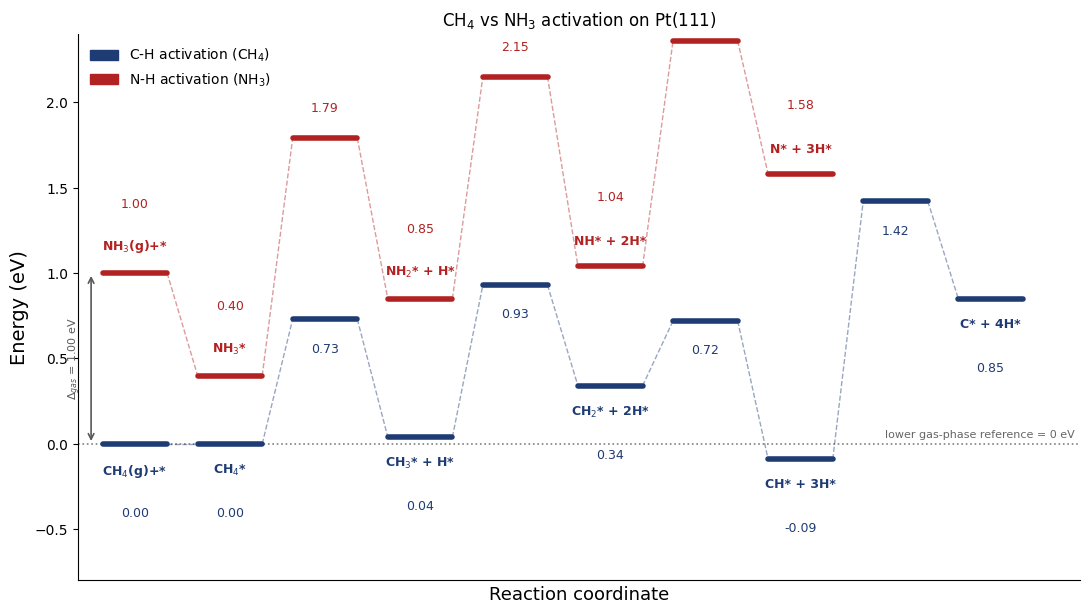

In [5]:
ax.set_title("CH$_4$ vs NH$_3$ activation on Pt(111)")
ax.set_ylim(-0.8, 2.4)
fig.savefig("my_pes.png", dpi=300, bbox_inches="tight")
fig            # re-display the edited figure

## Quick reference

| want to... | do this |
|---|---|
| add a barrier | third item `"ts"`: `("TS", 1.21, "ts")` |
| set the zero to a state | `PESDiagram(reference="NH$_3$(g) + *")` |
| overlay a 2nd path | call `add_path(...)` again with another `color` and `label_side="above"` |
| common gas reference | give each path a `gas_energy`; lower one becomes 0 |
| shift a whole branch | change that path's `gas_energy` |
| chain barriers into a profile | `build_ladder(reactant, [(Ea, dE, product), ...])` |
| add an adsorption well | `build_ladder(..., adsorbate_label="X*", E_ads=0.6)` |
| show a diffusion branch | `add_branch(name, [(attach_label, energy), ...])` |
| save | `fig.savefig("out.png", dpi=300, bbox_inches="tight")` |